# 衣橱内搭配（加载训练好的 checkpoint）\n\n按顺序运行所有 cell：加载 checkpoint → 从衣橱目录采样组合 → 打分排序 → 可视化 Top-K。\n

In [11]:
from pathlib import Path

def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "polyvore_route_a.py").exists():
            return p
    raise FileNotFoundError("polyvore_route_a.py not found")

project_root = find_project_root()

checkpoint_path = project_root / "models" / "cp_best_seed43.pth"
if not checkpoint_path.exists():
    checkpoint_path = project_root / "models" / "cp_from_notebook.pt"
if not checkpoint_path.exists():
    checkpoint_path = project_root / "models" / "cp_bilstm.pt"

def _dir_has_images(root: Path) -> bool:
    if not root.exists():
        return False
    exts = {".jpg", ".jpeg", ".png", ".webp"}
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            return True
    return False

processed_closet_root = project_root / "user_closet_processed"
demo_closet_root = project_root / "user_closet_demo"

closet_root = processed_closet_root if _dir_has_images(processed_closet_root) else demo_closet_root

slots = ["top", "pants", "shoes", "bag"]
top_k = 5

print("project_root=", project_root)
print("checkpoint_path=", checkpoint_path, "exists=", checkpoint_path.exists())
print("processed_closet_root=", processed_closet_root, "has_images=", _dir_has_images(processed_closet_root))
print("closet_root=", closet_root, "exists=", closet_root.exists())


project_root= D:\Projects\JupyterProject\COMP7065_GROUP
checkpoint_path= D:\Projects\JupyterProject\COMP7065_GROUP\models\cp_best_seed43.pth exists= True
processed_closet_root= D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed has_images= True
closet_root= D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed exists= True


In [12]:
import random
import heapq
import itertools

import torch
from PIL import Image

from polyvore_route_a import build_default_transform
from polyvore_route_a import list_closet_images_by_slot
from polyvore_route_a import load_checkpoint_model
from polyvore_route_a import score_outfit_paths

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, ckpt_args = load_checkpoint_model(str(checkpoint_path), device)
image_size = int(ckpt_args.get("image_size", 224))
transform = build_default_transform(image_size)

closet = list_closet_images_by_slot(str(closet_root))
print("device=", device)
print("slots_in_closet=", sorted(list(closet.keys()))[:10], "... total=", len(closet))


device= cuda
slots_in_closet= ['bag', 'dress', 'pants', 'rings', 'shoes', 'skirt', 'top'] ... total= 7


In [13]:
seed = 42
rng = random.Random(seed)

max_candidates_per_slot = 30
max_combinations = 5000
num_samples = 2000

pools = {}
for s in slots:
    arr = list(closet.get(s, []))
    if not arr:
        raise RuntimeError(f"No images found for slot={s} under {closet_root}")
    if len(arr) > max_candidates_per_slot:
        arr = rng.sample(arr, k=max_candidates_per_slot)
    pools[s] = arr

fixed = {}
if "top" in pools:
    fixed["top"] = pools["top"][0]
    pools["top"] = [fixed["top"]]

total_combinations = 1
for s in slots:
    total_combinations *= len(pools[s])

print("fixed=", fixed)
print("total_combinations=", total_combinations)


fixed= {'top': 'D:\\Projects\\JupyterProject\\COMP7065_GROUP\\user_closet_processed\\top\\179736869_1_clean.png'}
total_combinations= 80


In [14]:
def sample_outfit() -> list[str]:
    return [rng.choice(pools[s]) for s in slots]

if total_combinations <= max_combinations:
    iterable = itertools.product(*[pools[s] for s in slots])
    outfits = (list(t) for t in iterable)
else:
    outfits = (sample_outfit() for _ in range(num_samples))

heap = []
for outfit in outfits:
    score = score_outfit_paths(model=model, transform=transform, device=device, outfit_paths=outfit)
    if len(heap) < top_k:
        heapq.heappush(heap, (score, outfit))
    else:
        heapq.heappushpop(heap, (score, outfit))

best = sorted(heap, key=lambda x: x[0], reverse=True)
for i, (score, outfit) in enumerate(best, start=1):
    print(f"rank={i} score={score:.4f}")
    for s, p in zip(slots, outfit):
        print("  ", s, "->", p)


rank=1 score=0.7496
   top -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\top\179736869_1_clean.png
   pants -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\pants\207159426_3_clean.png
   shoes -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\shoes\21114051_5_raw.png
   bag -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\bag\19048977_6_raw.png
rank=2 score=0.7485
   top -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\top\179736869_1_clean.png
   pants -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\pants\19277222_2_clean.png
   shoes -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\shoes\21114051_5_raw.png
   bag -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\bag\19048977_6_raw.png
rank=3 score=0.7471
   top -> D:\Projects\JupyterProject\COMP7065_GROUP\user_closet_processed\top\179736869_1_clean.png
   pants -> D:\Projects\JupyterProjec

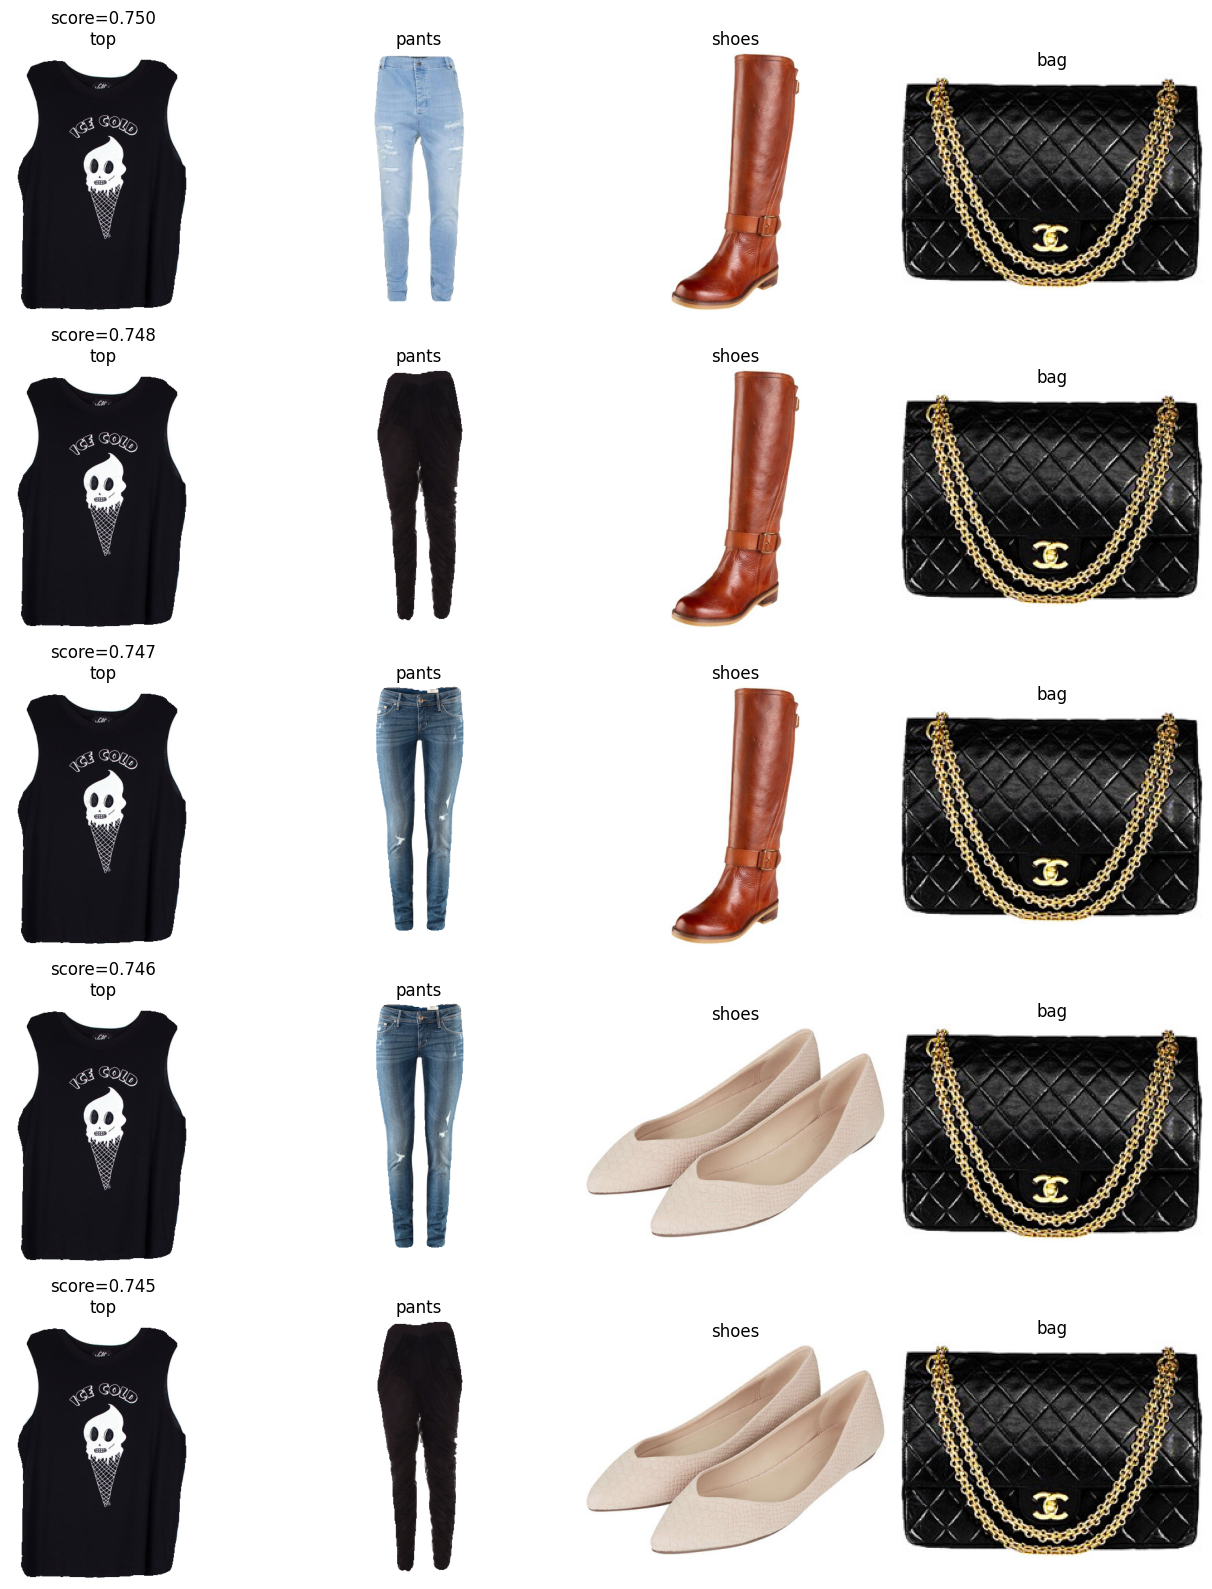

In [15]:
try:
    import matplotlib.pyplot as plt

    show_k = min(top_k, 5)
    fig, axes = plt.subplots(show_k, len(slots), figsize=(3.2 * len(slots), 3.2 * show_k))
    if show_k == 1:
        axes = [axes]
    for r in range(show_k):
        score, outfit = best[r]
        row_axes = axes[r]
        for c, (slot, path) in enumerate(zip(slots, outfit)):
            ax = row_axes[c] if hasattr(row_axes, "__len__") else row_axes
            img = Image.open(path).convert("RGB")
            ax.imshow(img)
            if c == 0:
                ax.set_title(f"score={score:.3f}\n{slot}")
            else:
                ax.set_title(slot)
            ax.axis("off")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("matplotlib 不可用，跳过可视化：", repr(e))
